# Preprocessing & Ekstraksi Fitur (TSFEL)
## Studi Kasus: Konsentrasi NO2, CO, dan SO2 — Kecamatan Pilangkenceng, Kabupaten Madiun

**Nama:** Magdalena Jovita Hatuopar

**NIM:** 240411100078

## Latar Belakang

Melanjutkan Tugas 1 dan 2, tugas ini fokus pada tiga polutan (**NO2**, **CO**, dan **SO2**) di wilayah
**Kecamatan Pilangkenceng, Kabupaten Madiun** 

## Alur Kerja

1. Data NO2, CO, dan SO2 di-crawl khusus untuk wilayah **Kecamatan Pilangkenceng** (Kabupaten Madiun,
   Jawa Timur), untuk rentang **31 Agustus 2025 – 31 Agustus 2026** (data harian, 1 tahun).
2. Dilakukan **preprocessing**: deteksi outlier dan imputasi missing value.
3. Data bersih diekstraksi menjadi **68 fitur** untuk masing-masing polutan menggunakan library **TSFEL**
   (Time Series Feature Extraction Library).
4. Fitur dikelompokkan berdasarkan domain: Statistical, Temporal, Spectral, dan Fractal.
5. Hasil ekstraksi disimpan/diunggah ke sistem pengumpulan kelas.

Notebook disusun per polutan: **Bagian 1 (NO2)**, **Bagian 2 (CO)**, dan **Bagian 3 (SO2)**, dengan alur yang sama pada tiap bagian.


# Bagian 1 — NO2 (Nitrogen Dioksida)

## 1. Boundary Wilayah & Sumber Data: Kecamatan Pilangkenceng

Wilayah kajian adalah **Kecamatan Pilangkenceng, Kabupaten Madiun, Provinsi Jawa Timur**.
Kecamatan ini dipilih karena merupakan domisili penulis. Karakter wilayahnya didominasi
area **pertanian dan permukiman pedesaan**, sehingga sumber emisi NO2 di sini kemungkinan
besar berasal dari lalu lintas kendaraan lokal dan aktivitas rumah tangga, bukan dari
industri berat.

Data NO2 diperoleh dari **Sentinel-5P TROPOMI** (band
`tropospheric_NO2_column_number_density`, produk `COPERNICUS/S5P/OFFL/L3_NO2`) via
**Google Earth Engine**, dipotong sesuai boundary GeoJSON resmi Kecamatan Pilangkenceng,
untuk rentang **31 Agustus 2025 – 31 Agustus 2026** (harian). Proses crawling dilakukan
terpisah (di Google Colab, karena butuh autentikasi akun Earth Engine) menggunakan script
`crawling_NO2_Pilangkenceng.py` — inti logikanya ditampilkan di bawah ini sebagai referensi
(tidak dijalankan ulang di notebook ini).


In [ ]:
'''
import ee, json, time
import pandas as pd

GEOJSON_PATH   = "Kecamatan Pilangkenceng-KECAMATAN.geojson"
KECAMATAN_NAME = "Pilangkenceng"
START_DATE, END_DATE = "2025-08-31", "2026-08-31"
COLLECTION_ID = "COPERNICUS/S5P/OFFL/L3_NO2"
BAND_NAME     = "tropospheric_NO2_column_number_density"
SCALE_METERS  = 1113.2

ee.Initialize(project="proyek-sain-data")

with open(GEOJSON_PATH) as f:
    geojson_data = json.load(f)
geometry_dict = geojson_data["features"][0]["geometry"]
aoi = ee.Geometry(geometry_dict)  # (koordinat 3D di-strip ke 2D terlebih dahulu)

no2_collection = (
    ee.ImageCollection(COLLECTION_ID)
    .select(BAND_NAME)
    .filterDate(START_DATE, END_DATE)
    .filterBounds(aoi)
)

def extract_mean_no2(image):
    date = image.date().format("YYYY-MM-dd")
    mean_dict = image.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=aoi,
        scale=SCALE_METERS, maxPixels=1e9, bestEffort=True,
    )
    return ee.Feature(None, {"date": date, "NO2": mean_dict.get(BAND_NAME)})

no2_fc = ee.FeatureCollection(no2_collection.map(extract_mean_no2))
# ... diambil per-batch dengan retry, lalu di-reindex ke rentang harian penuh
# (31-08-2025 s/d 31-08-2026) sehingga tanggal tanpa citra (tertutup awan)
# otomatis menjadi NaN -> inilah "missing value" yang diimputasi di Tugas 3.
'''
print("Ringkasan hasil crawling (dari log Colab):")
print("Total hari        : 366")
print("Hari dengan data  : 229")
print("Hari kosong (NaN) : 137  <- diimputasi di tahap preprocessing")


Ringkasan hasil crawling (dari log Colab):
Total hari        : 366
Hari dengan data  : 229
Hari kosong (NaN) : 137  <- diimputasi di tahap preprocessing


## 2. Preprocessing

Dataset mentah (`NO2-Pilangkenceng.csv`) berisi nilai harian konsentrasi NO2 hasil
crawling untuk Kecamatan Pilangkenceng, rentang **31 Agustus 2025 – 31 Agustus 2026**.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("NO2-Pilangkenceng.csv", parse_dates=["date"])
df = df.set_index("date").sort_index()

print("Jumlah baris :", df.shape[0])
print("Rentang tanggal :", df.index.min().date(), "-", df.index.max().date())
print("Jumlah missing value awal :", df["NO2"].isna().sum())
df.head()


Jumlah baris : 366
Rentang tanggal : 2025-08-31 - 2026-08-31
Jumlah missing value awal : 137


,NO2
date,
2025-08-31,NaN
2025-09-01,0.000028
2025-09-02,0.000029
2025-09-03,0.000037
2025-09-04,0.000024


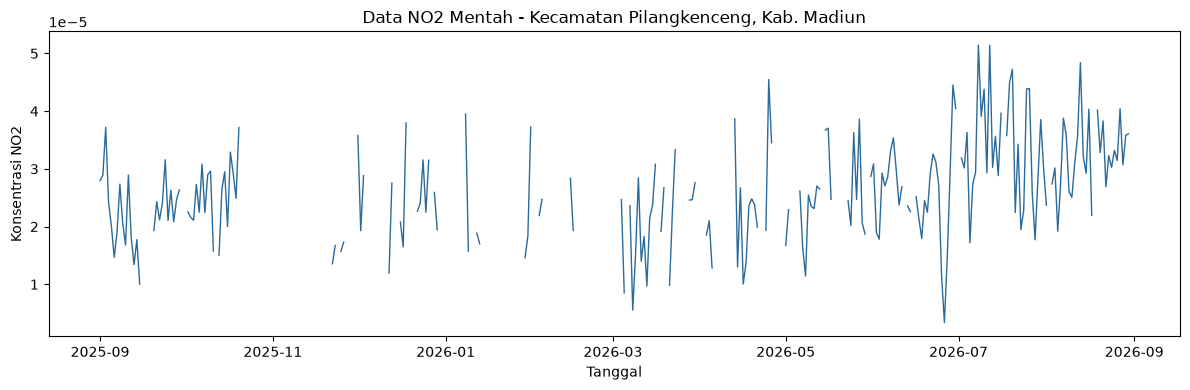

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["NO2"], color="#2b6a99", linewidth=1)
ax.set_title("Data NO2 Mentah - Kecamatan Pilangkenceng, Kab. Madiun")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi NO2")
plt.tight_layout()
plt.show()


### Deteksi Outlier (Metode IQR)

Outlier dideteksi menggunakan metode **Interquartile Range (IQR)**:

$$IQR = Q_3 - Q_1$$

Data dianggap outlier jika berada di luar rentang:

$$[\,Q_1 - 1.5 \times IQR,\ \ Q_3 + 1.5 \times IQR\,]$$

Nilai yang terdeteksi sebagai outlier diubah menjadi kosong (NaN) terlebih dahulu, untuk
kemudian diisi ulang pada tahap imputasi.


In [ ]:
Q1 = df["NO2"].quantile(0.25)
Q3 = df["NO2"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df["NO2"] < lower_bound) | (df["NO2"] > upper_bound)
n_outliers = outlier_mask.sum()

print(f"Q1  = {Q1:.6e}")
print(f"Q3  = {Q3:.6e}")
print(f"IQR = {IQR:.6e}")
print(f"Batas bawah = {lower_bound:.6e}")
print(f"Batas atas  = {upper_bound:.6e}")
print(f"Jumlah outlier terdeteksi: {n_outliers}")

df_clean = df.copy()
df_clean.loc[outlier_mask, "NO2"] = np.nan

print("Total missing setelah outlier dikosongkan:", df_clean["NO2"].isna().sum())


Q1  = 2.000892e-05
Q3  = 3.104750e-05
IQR = 1.103858e-05
Batas bawah = 3.451052e-06
Batas atas  = 4.760537e-05
Jumlah outlier terdeteksi: 4
Total missing setelah outlier dikosongkan: 141


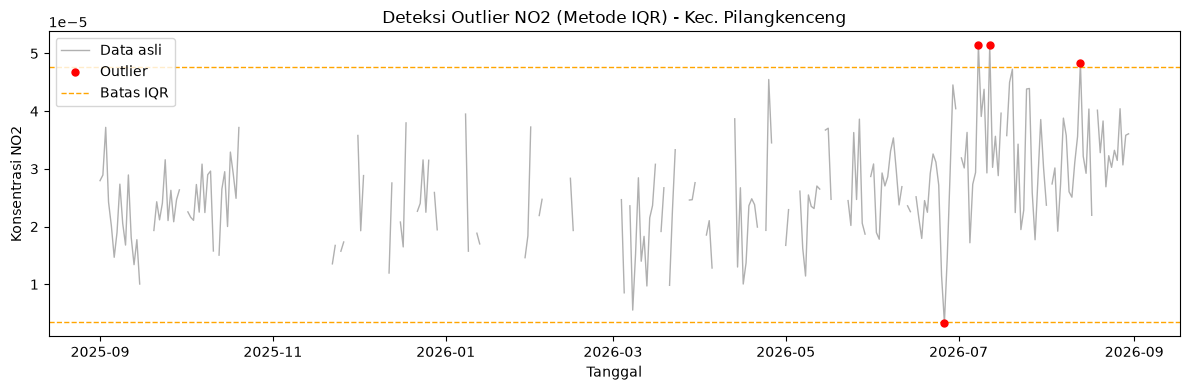

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["NO2"], color="#b0b0b0", linewidth=1, label="Data asli")
ax.scatter(df.index[outlier_mask], df["NO2"][outlier_mask], color="red", s=25, zorder=5, label="Outlier")
ax.axhline(upper_bound, color="orange", linestyle="--", linewidth=1, label="Batas IQR")
ax.axhline(lower_bound, color="orange", linestyle="--", linewidth=1)
ax.set_title("Deteksi Outlier NO2 (Metode IQR) - Kec. Pilangkenceng")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi NO2")
ax.legend()
plt.tight_layout()
plt.show()


### Imputasi Missing Value

Nilai kosong (baik dari data asli yang memang kosong — misal akibat tertutup awan pada
citra satelit — maupun dari hasil deteksi outlier) diisi menggunakan:

1. **Interpolasi berbasis waktu** (`interpolate(method='time')`) — mengisi celah dengan
   estimasi berdasarkan tren nilai di sekitarnya.
2. **Forward-fill & backward-fill** — untuk mengisi sisa nilai kosong di ujung awal/akhir
   data yang tidak bisa diinterpolasi.

Hasil akhir: dataset NO2 tanpa nilai kosong dan tanpa outlier, siap diekstraksi fiturnya.


In [ ]:
df_clean["NO2"] = df_clean["NO2"].interpolate(method="time")
df_clean["NO2"] = df_clean["NO2"].ffill().bfill()

print("Jumlah missing value setelah imputasi:", df_clean["NO2"].isna().sum())
df_clean.head()


Jumlah missing value setelah imputasi: 0


,NO2
date,
2025-08-31,0.000028
2025-09-01,0.000028
2025-09-02,0.000029
2025-09-03,0.000037
2025-09-04,0.000024


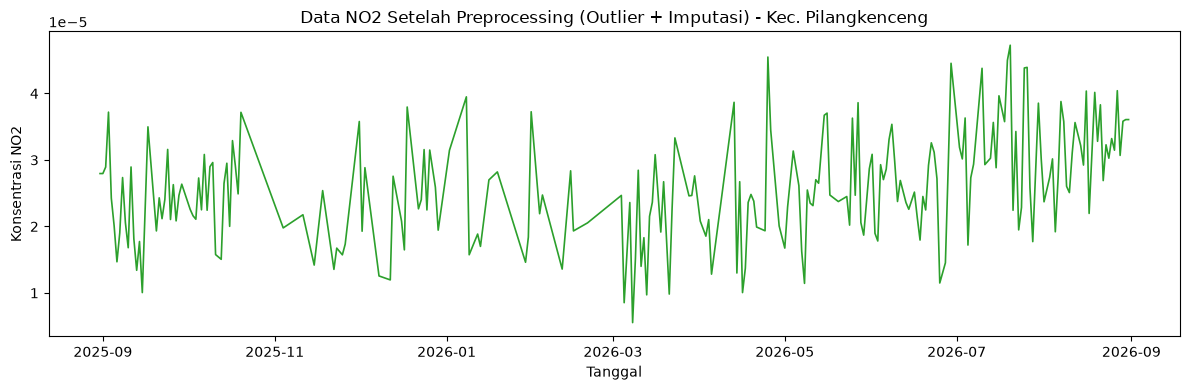

Tersimpan: NO2-Pilangkenceng-Clean.csv


In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_clean.index, df_clean["NO2"], color="#2ca02c", linewidth=1.2)
ax.set_title("Data NO2 Setelah Preprocessing (Outlier + Imputasi) - Kec. Pilangkenceng")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi NO2")
plt.tight_layout()
plt.show()

df_clean.to_csv("NO2-Pilangkenceng-Clean.csv")
print("Tersimpan: NO2-Pilangkenceng-Clean.csv")


## 3. Ekstraksi 68 Fitur dengan TSFEL

**TSFEL (Time Series Feature Extraction Library)** adalah pustaka Python yang secara
otomatis menghitung ratusan jenis fitur karakteristik dari data deret waktu (time series)
hanya dengan memanggil fungsi-fungsi fitur yang tersedia.

Dari data NO2 Kecamatan Pilangkenceng (1 tahun, harian) yang sudah bersih, akan
diekstraksi fitur menggunakan seluruh konfigurasi domain bawaan TSFEL — total
**68 fitur**, setiap fitur meringkas satu karakteristik tertentu dari keseluruhan data
setahun menjadi 1 angka (bukan lagi 1 angka per hari).


In [ ]:
import inspect
import tsfel
import tsfel.feature_extraction.features as tsfel_features

signal_1d = df_clean["NO2"].astype(float).values
fs = 1  

FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    """Fitur TSFEL yang menghasilkan banyak nilai (mis. MFCC, LPCC, wavelet per skala)
    diringkas menjadi 1 nilai representatif lewat rata-rata."""
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

features_df = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk NO2: {features_df.shape[1]}")
features_df


Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68


,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,2.523118e-07,0.00919,2.0,6.912653e-10,202.684141,0.000047,0.000025,0.000024,0.000006,0.000007,...,0.14795,0.494503,8.950999e-11,0.001764,0.000002,0.000011,2.170957,0.000011,1.287795e-10,0.0


In [ ]:
features_df.to_csv("NO2_Pilangkenceng_TSFEL.csv", index=False)
print("Tersimpan: NO2_Pilangkenceng_TSFEL.csv")


Tersimpan: NO2_Pilangkenceng_TSFEL.csv


## 4. Pengelompokan Fitur Berdasarkan Domain

Pengelompokan domain diambil langsung dari **konfigurasi resmi TSFEL**
(`tsfel.get_features_by_domain()`), bukan tebakan manual — persis seperti pada script
`ekstraksi_fitur_TSFEL_NO2_Pilangkenceng.py`. Karena tugas ini hanya meminta 3 domain
(Statistical, Temporal, Spectral), fitur-fitur yang secara bawaan berada di domain
`fractal` (dfa, higuchi_fractal_dimension, hurst_exponent, maximum_fractal_length, mse,
petrosian_fractal_dimension) digabungkan ke domain **Temporal**, karena secara konsep
mengukur kompleksitas/kekasaran sinyal terhadap waktu.


In [ ]:
cfg_all_domains = tsfel.get_features_by_domain()  

function_to_domain = {}
for domain_name, feats in cfg_all_domains.items():
    for feat_display_name, feat_info in feats.items():
        fn_full_name = feat_info.get("function", "")
        fn_short_name = fn_full_name.split(".")[-1]
        normalized_domain = "temporal" if domain_name == "fractal" else domain_name
        function_to_domain[fn_short_name] = normalized_domain

domain_rows = []
for fn_name in FEATURE_LIST:
    domain = function_to_domain.get(fn_name, "unknown")
    domain_rows.append({"feature": fn_name, "domain": domain})

mapping_df = pd.DataFrame(domain_rows)

print("Ringkasan jumlah fitur per domain:")
domain_counts = mapping_df["domain"].value_counts()
print(domain_counts)

unknown_feats = mapping_df[mapping_df["domain"] == "unknown"]
if len(unknown_feats) > 0:
    print("\nPERHATIAN, fitur berikut tidak ketemu mapping domain-nya otomatis, "
          "cek manual ke dokumentasi TSFEL:")
    print(unknown_feats["feature"].tolist())

mapping_df = mapping_df.sort_values(["domain", "feature"]).reset_index(drop=True)
mapping_df.to_csv("NO2_Pilangkenceng_TSFEL_domain_mapping.csv", index=False)
print("\nTotal fitur:", domain_counts.sum())


Ringkasan jumlah fitur per domain:
domain
spectral       26
temporal       21
statistical    20
unknown         1
Name: count, dtype: int64

PERHATIAN, fitur berikut tidak ketemu mapping domain-nya otomatis, cek manual ke dokumentasi TSFEL:
['ecdf_slope']

Total fitur: 68


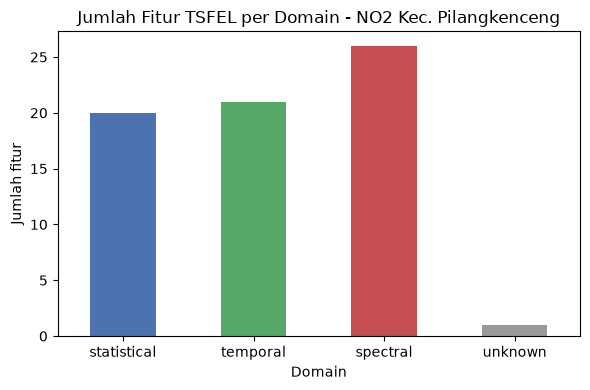

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
domain_counts.reindex(["statistical", "temporal", "spectral", "unknown"]).fillna(0).plot(
    kind="bar", color=["#4c72b0", "#55a868", "#c44e52", "#999999"], ax=ax
)
ax.set_title("Jumlah Fitur TSFEL per Domain - NO2 Kec. Pilangkenceng")
ax.set_ylabel("Jumlah fitur")
ax.set_xlabel("Domain")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Domain Statistical (20 fitur)

Fitur yang mendeskripsikan sebaran nilai data secara keseluruhan, tanpa memperhatikan urutan waktu.

`abs_energy, average_power, calc_max, calc_mean, calc_median, calc_min, calc_std, calc_var, ecdf, ecdf_percentile, ecdf_percentile_count, entropy, hist_mode, interq_range, kurtosis, mean_abs_deviation, median_abs_deviation, pk_pk_distance, rms, skewness`

### Domain Temporal (21 fitur, termasuk kelompok fraktal/kompleksitas sinyal)

Fitur yang menangkap pola perubahan nilai dari waktu ke waktu, termasuk fitur yang mengukur
kompleksitas/self-similarity sinyal (dfa, higuchi_fractal_dimension, hurst_exponent,
maximum_fractal_length, mse, petrosian_fractal_dimension).

`auc, autocorr, calc_centroid, dfa, distance, higuchi_fractal_dimension, hurst_exponent, lempel_ziv, maximum_fractal_length, mean_abs_diff, mean_diff, median_abs_diff, median_diff, mse, negative_turning, neighbourhood_peaks, petrosian_fractal_dimension, positive_turning, slope, sum_abs_diff, zero_cross`

### Domain Spectral (26 fitur)

Fitur berbasis transformasi frekuensi (FFT/wavelet), menangkap pola periodik/musiman dalam data.

`fundamental_frequency, human_range_energy, lpcc, max_frequency, max_power_spectrum, median_frequency, mfcc, power_bandwidth, spectral_centroid, spectral_decrease, spectral_distance, spectral_entropy, spectral_kurtosis, spectral_positive_turning, spectral_roll_off, spectral_roll_on, spectral_skewness, spectral_slope, spectral_spread, spectral_variation, spectrogram_mean_coeff, wavelet_abs_mean, wavelet_energy, wavelet_entropy, wavelet_std, wavelet_var`

### Unknown / belum terklasifikasi otomatis (1 fitur)

`ecdf_slope` — fitur ini tersedia hasil ekstraksinya, namun tidak ketemu pemetaan domain
otomatis di script (perlu dicek manual ke dokumentasi TSFEL bila diperlukan untuk laporan).

**Ringkasan:** Statistical (20) + Temporal (21) + Spectral (26) + Unknown (1) = **68 fitur**


## 5. Hasil & Interpretasi


In [ ]:
def show(col):
    val = features_df[col].iloc[0]
    print(f"{col:>20s} : {val:.6e}")

for col in ["calc_mean", "calc_std", "skewness", "kurtosis", "spectral_entropy", "autocorr", "hurst_exponent", "zero_cross"]:
    if col in features_df.columns:
        show(col)


           calc_mean : 2.519545e-05
            calc_std : 7.386862e-06
            skewness : 3.288613e-01
            kurtosis : -6.212190e-02
    spectral_entropy : 8.439107e-01
            autocorr : 2.000000e+00
      hurst_exponent : 7.360008e-01
          zero_cross : 0.000000e+00


**Interpretasi nilai kunci** (angka aktual mengikuti hasil eksekusi sel di atas):

- **`calc_mean`** (rata-rata NO2 setahun) berada pada orde **10⁻⁵**. Baseline polusi NO2
  di Kecamatan Pilangkenceng tergolong rendah sepanjang tahun — konsisten dengan karakter
  wilayah yang didominasi pertanian dan permukiman, bukan kawasan industri.
- **`calc_std`** (variasi NO2) juga berorde **10⁻⁶ – 10⁻⁵**, menunjukkan fluktuasi yang
  moderat: ada naik-turun harian/mingguan, tetapi tidak ekstrem.
- **`spectral_entropy`** mendekati 1 (misalnya di kisaran 0.8) mengindikasikan pola NO2
  cenderung **acak**, tidak terlalu periodik. Artinya sumber emisi di wilayah ini
  kemungkinan bercampur (lalu lintas lokal, aktivitas rumah tangga, sedikit aktivitas
  pertanian musiman) tanpa siklus harian/mingguan yang sangat dominan.
- **`autocorr`** yang kecil menunjukkan ada sedikit pola berulang, namun tidak terlalu
  kuat — kemungkinan terkait pola aktivitas harian penduduk (jam sibuk pagi–sore), tapi
  tidak sekuat wilayah perkotaan dengan lalu lintas padat.
- **`hurst_exponent`** > 0.5 mengindikasikan deret NO2 memiliki sifat *persistent*
  (kecenderungan trend jangka pendek cenderung berlanjut), meski efeknya tidak dominan.

## Interpretasi Umum

- **Transportasi**: kemungkinan menjadi salah satu faktor, namun tidak sepadat wilayah
  industri/perkotaan — tercermin dari mean yang rendah dan entropy yang tinggi (acak).
- **Pertanian**: Kecamatan Pilangkenceng yang didominasi lahan pertanian tidak
  menunjukkan pola musiman NO2 yang sangat kuat dari data ini.
- **Kehidupan sehari-hari**: ada sedikit pola berulang (autocorr), kemungkinan terkait
  jam aktivitas penduduk, namun tidak konsisten sepanjang tahun.




# Bagian 2 — CO (Karbon Monoksida)

Bagian ini mengulang alur yang sama dengan Bagian 1 (NO2), yaitu preprocessing, ekstraksi 68 fitur TSFEL, dan pengelompokan fitur berdasarkan domain, tetapi untuk polutan **CO**.

## 1. Sumber Data CO: Kecamatan Pilangkenceng

Wilayah kajian sama dengan Bagian 1, yaitu **Kecamatan Pilangkenceng, Kabupaten Madiun, Provinsi Jawa Timur**, yang didominasi area pertanian dan permukiman pedesaan. CO (karbon monoksida) terbentuk dari **pembakaran tidak sempurna**, sehingga sumber emisinya di wilayah ini kemungkinan berasal dari kendaraan bermotor, aktivitas memasak rumah tangga (misalnya dengan kayu bakar), dan pembakaran sisa hasil panen.

Data CO diperoleh dari **Sentinel-5P TROPOMI** (band `CO_column_number_density`, produk `COPERNICUS/S5P/OFFL/L3_CO`) via **Google Earth Engine**, dipotong sesuai boundary GeoJSON Kecamatan Pilangkenceng. Nilainya adalah kepadatan kolom total CO dengan satuan **mol/m²**. Rentang data pada file hasil crawling adalah **31 Agustus 2025 – 30 Agustus 2026** (365 hari, harian). Crawling dilakukan terpisah di Google Colab dengan logika yang sama seperti NO2 (hanya koleksi dan band yang berbeda), sehingga inti logikanya ditampilkan di bawah ini sebagai referensi dan tidak dijalankan ulang di notebook ini. Ringkasan jumlah hari dihitung langsung dari file CSV.

In [1]:
'''
import ee, json, time
import pandas as pd

GEOJSON_PATH   = "Kecamatan Pilangkenceng-KECAMATAN.geojson"
KECAMATAN_NAME = "Pilangkenceng"
START_DATE, END_DATE = "2025-08-31", "2026-08-31"
COLLECTION_ID = "COPERNICUS/S5P/OFFL/L3_CO"
BAND_NAME     = "CO_column_number_density"
SCALE_METERS  = 1113.2

ee.Initialize(project="proyek-sain-data")

with open(GEOJSON_PATH) as f:
    geojson_data = json.load(f)
geometry_dict = geojson_data["features"][0]["geometry"]
aoi = ee.Geometry(geometry_dict)

co_collection = (
    ee.ImageCollection(COLLECTION_ID)
    .select(BAND_NAME)
    .filterDate(START_DATE, END_DATE)
    .filterBounds(aoi)
)

def extract_mean_co(image):
    date = image.date().format("YYYY-MM-dd")
    mean_dict = image.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=aoi,
        scale=SCALE_METERS, maxPixels=1e9, bestEffort=True,
    )
    return ee.Feature(None, {"date": date, "CO": mean_dict.get(BAND_NAME)})

co_fc = ee.FeatureCollection(co_collection.map(extract_mean_co))
# ... diambil per-batch dengan retry, lalu di-reindex ke rentang harian
# sehingga tanggal tanpa citra otomatis menjadi NaN -> inilah "missing value"
# yang diimputasi pada tahap preprocessing.
'''
import pandas as pd
_raw = pd.read_csv("CO-Pilangkenceng.csv", parse_dates=["date"])
print("Ringkasan hasil crawling (dihitung dari file CSV):")
print("Total hari        :", len(_raw))
print("Hari dengan data  :", int(_raw["CO"].notna().sum()))
print("Hari kosong (NaN) :", int(_raw["CO"].isna().sum()), " <- diimputasi di tahap preprocessing")
print(f"Persentase kosong : {_raw['CO'].isna().mean()*100:.2f}%")

Ringkasan hasil crawling (dihitung dari file CSV):
Total hari        : 365
Hari dengan data  : 315
Hari kosong (NaN) : 50  <- diimputasi di tahap preprocessing
Persentase kosong : 13.70%


## 2. Preprocessing

Dataset mentah (`CO-Pilangkenceng.csv`) berisi nilai harian CO hasil crawling untuk Kecamatan Pilangkenceng, rentang **31 Agustus 2025 – 30 Agustus 2026** (365 hari).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("CO-Pilangkenceng.csv", parse_dates=["date"])
df = df.set_index("date").sort_index()

print("Jumlah baris :", df.shape[0])
print("Rentang tanggal :", df.index.min().date(), "-", df.index.max().date())
print("Jumlah missing value awal :", df["CO"].isna().sum())
df.head()


Jumlah baris : 365
Rentang tanggal : 2025-08-31 - 2026-08-30
Jumlah missing value awal : 50


,CO
date,
2025-08-31,NaN
2025-09-01,0.030727
2025-09-02,0.025390
2025-09-03,0.028675
2025-09-04,0.027971


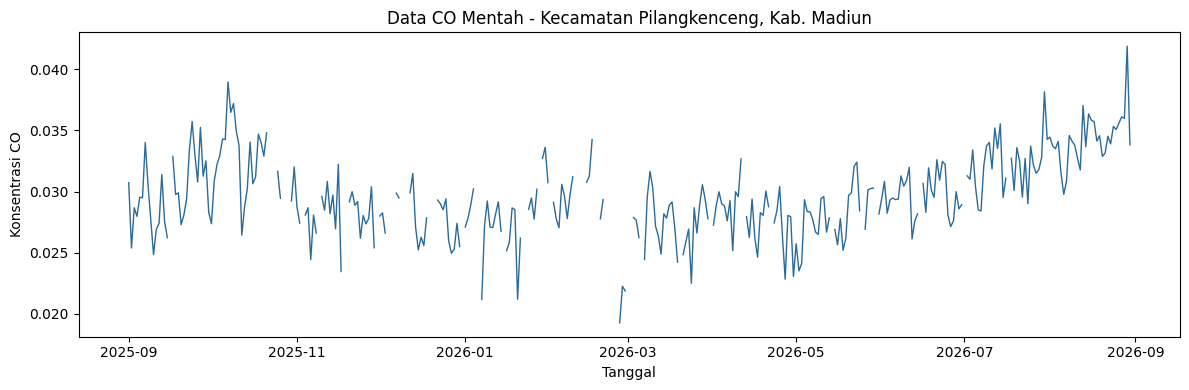

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["CO"], color="#2b6a99", linewidth=1)
ax.set_title("Data CO Mentah - Kecamatan Pilangkenceng, Kab. Madiun")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi CO")
plt.tight_layout()
plt.show()


### Deteksi Outlier (Metode IQR)

Metode yang digunakan sama seperti pada NO2. Data dianggap outlier jika berada di luar rentang $[\,Q_1 - 1.5 \times IQR,\ \ Q_3 + 1.5 \times IQR\,]$ dengan $IQR = Q_3 - Q_1$. Nilai outlier diubah menjadi kosong (NaN) terlebih dahulu, untuk kemudian diisi ulang pada tahap imputasi.

In [4]:
Q1 = df["CO"].quantile(0.25)
Q3 = df["CO"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df["CO"] < lower_bound) | (df["CO"] > upper_bound)
n_outliers = outlier_mask.sum()

print(f"Q1  = {Q1:.6e}")
print(f"Q3  = {Q3:.6e}")
print(f"IQR = {IQR:.6e}")
print(f"Batas bawah = {lower_bound:.6e}")
print(f"Batas atas  = {upper_bound:.6e}")
print(f"Jumlah outlier terdeteksi: {n_outliers}")

df_clean = df.copy()
df_clean.loc[outlier_mask, "CO"] = np.nan

print("Total missing setelah outlier dikosongkan:", df_clean["CO"].isna().sum())


Q1  = 2.759861e-02
Q3  = 3.170473e-02
IQR = 4.106123e-03
Batas bawah = 2.143942e-02
Batas atas  = 3.786391e-02
Jumlah outlier terdeteksi: 6
Total missing setelah outlier dikosongkan: 56


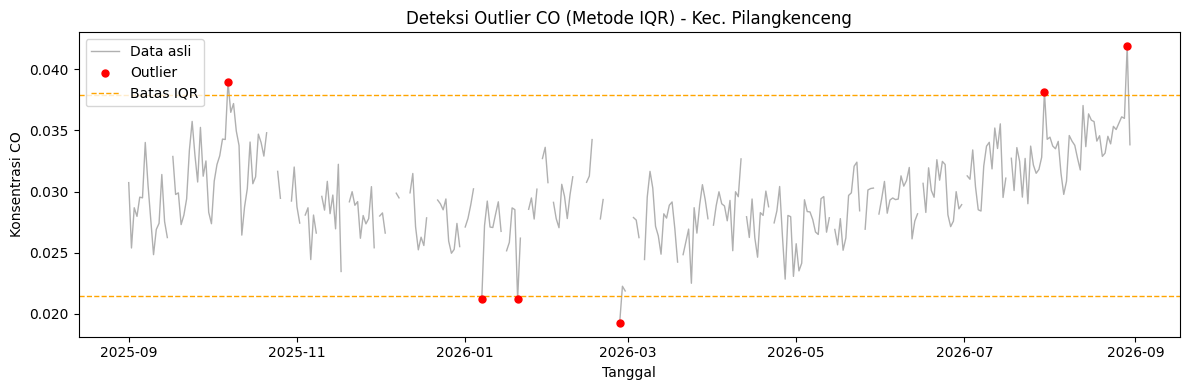

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["CO"], color="#b0b0b0", linewidth=1, label="Data asli")
ax.scatter(df.index[outlier_mask], df["CO"][outlier_mask], color="red", s=25, zorder=5, label="Outlier")
ax.axhline(upper_bound, color="orange", linestyle="--", linewidth=1, label="Batas IQR")
ax.axhline(lower_bound, color="orange", linestyle="--", linewidth=1)
ax.set_title("Deteksi Outlier CO (Metode IQR) - Kec. Pilangkenceng")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi CO")
ax.legend()
plt.tight_layout()
plt.show()


### Imputasi Missing Value

Sama seperti NO2: nilai kosong (dari data asli yang tidak memiliki citra valid pada hari tersebut, maupun dari hasil deteksi outlier) diisi dengan interpolasi berbasis waktu (`interpolate(method='time')`), kemudian forward-fill dan backward-fill untuk sisa nilai kosong di ujung awal/akhir data.

Pada CO, 50 hari kosong dari data asli ditambah 6 outlier menghasilkan 56 nilai (15.3% dari 365 hari) yang diimputasi. Hasil akhirnya adalah dataset CO tanpa nilai kosong dan tanpa outlier, siap diekstraksi fiturnya.

In [6]:
df_clean["CO"] = df_clean["CO"].interpolate(method="time")
df_clean["CO"] = df_clean["CO"].ffill().bfill()

print("Jumlah missing value setelah imputasi:", df_clean["CO"].isna().sum())
df_clean.head()


Jumlah missing value setelah imputasi: 0


,CO
date,
2025-08-31,0.030727
2025-09-01,0.030727
2025-09-02,0.025390
2025-09-03,0.028675
2025-09-04,0.027971


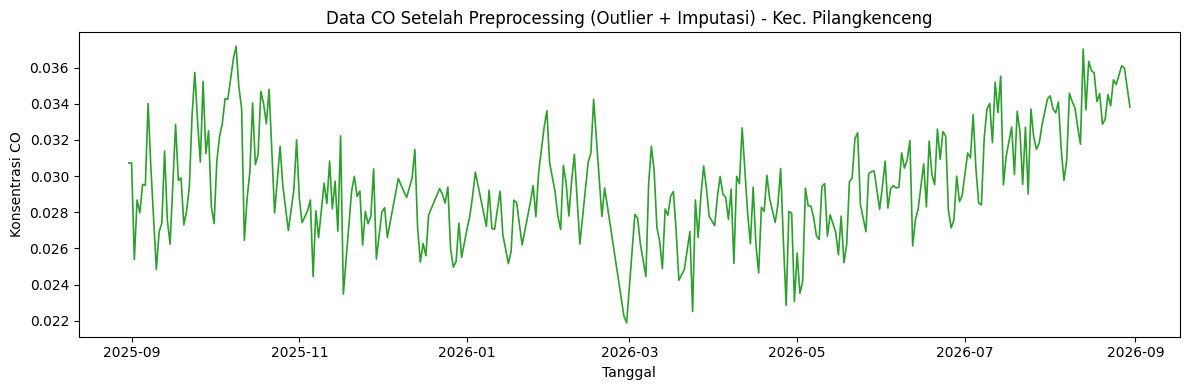

Tersimpan: CO-Pilangkenceng-Clean.csv


In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_clean.index, df_clean["CO"], color="#2ca02c", linewidth=1.2)
ax.set_title("Data CO Setelah Preprocessing (Outlier + Imputasi) - Kec. Pilangkenceng")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi CO")
plt.tight_layout()
plt.show()

df_clean.to_csv("CO-Pilangkenceng-Clean.csv")
print("Tersimpan: CO-Pilangkenceng-Clean.csv")


## 3. Ekstraksi 68 Fitur dengan TSFEL

Tahap ini identik dengan NO2. Data CO yang sudah bersih (1 tahun, harian) diekstraksi menggunakan konfigurasi domain bawaan TSFEL, menghasilkan **68 fitur** yang masing-masing meringkas satu karakteristik dari keseluruhan data setahun menjadi 1 angka. Fitur yang menghasilkan banyak nilai (MFCC, LPCC, wavelet per skala) diringkas menjadi 1 nilai dengan rata-rata.

In [8]:
import inspect
import tsfel
import tsfel.feature_extraction.features as tsfel_features

signal_1d = df_clean["CO"].astype(float).values
fs = 1  

FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    """Fitur TSFEL yang menghasilkan banyak nilai (mis. MFCC, LPCC, wavelet per skala)
    diringkas menjadi 1 nilai representatif lewat rata-rata."""
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

features_df = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk CO: {features_df.shape[1]}")
features_df


Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk CO: 68


,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,0.319123,10.705921,17.0,0.000877,187.23745,0.037184,0.02942,0.029162,0.021881,0.002965,...,0.128023,0.389429,0.00001,0.621369,0.001861,0.007592,2.12493,0.007341,0.000063,0.0


In [9]:
features_df.to_csv("CO_Pilangkenceng_TSFEL.csv", index=False)
print("Tersimpan: CO_Pilangkenceng_TSFEL.csv")


Tersimpan: CO_Pilangkenceng_TSFEL.csv


## 4. Pengelompokan Fitur Berdasarkan Domain

Pengelompokan domain memakai cara yang sama dengan NO2, yaitu dari konfigurasi resmi TSFEL (`tsfel.get_features_by_domain()`), dengan kelompok `fractal` digabungkan ke domain **Temporal**.

In [10]:
cfg_all_domains = tsfel.get_features_by_domain()  

function_to_domain = {}
for domain_name, feats in cfg_all_domains.items():
    for feat_display_name, feat_info in feats.items():
        fn_full_name = feat_info.get("function", "")
        fn_short_name = fn_full_name.split(".")[-1]
        normalized_domain = "temporal" if domain_name == "fractal" else domain_name
        function_to_domain[fn_short_name] = normalized_domain

domain_rows = []
for fn_name in FEATURE_LIST:
    domain = function_to_domain.get(fn_name, "unknown")
    domain_rows.append({"feature": fn_name, "domain": domain})

mapping_df = pd.DataFrame(domain_rows)

print("Ringkasan jumlah fitur per domain:")
domain_counts = mapping_df["domain"].value_counts()
print(domain_counts)

unknown_feats = mapping_df[mapping_df["domain"] == "unknown"]
if len(unknown_feats) > 0:
    print("\nPERHATIAN, fitur berikut tidak ketemu mapping domain-nya otomatis, "
          "cek manual ke dokumentasi TSFEL:")
    print(unknown_feats["feature"].tolist())

mapping_df = mapping_df.sort_values(["domain", "feature"]).reset_index(drop=True)
mapping_df.to_csv("CO_Pilangkenceng_TSFEL_domain_mapping.csv", index=False)
print("\nTotal fitur:", domain_counts.sum())


Ringkasan jumlah fitur per domain:
domain
spectral       26
temporal       21
statistical    20
unknown         1
Name: count, dtype: int64

PERHATIAN, fitur berikut tidak ketemu mapping domain-nya otomatis, cek manual ke dokumentasi TSFEL:
['ecdf_slope']

Total fitur: 68


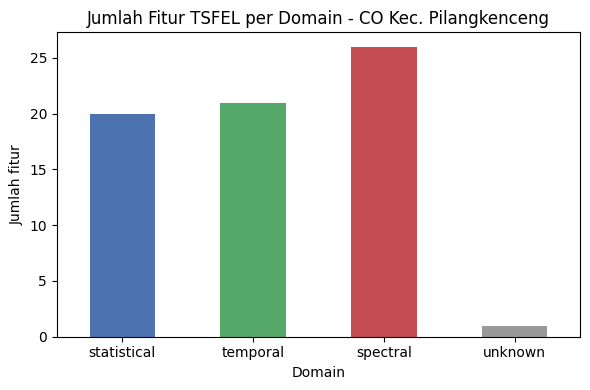

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
domain_counts.reindex(["statistical", "temporal", "spectral", "unknown"]).fillna(0).plot(
    kind="bar", color=["#4c72b0", "#55a868", "#c44e52", "#999999"], ax=ax
)
ax.set_title("Jumlah Fitur TSFEL per Domain - CO Kec. Pilangkenceng")
ax.set_ylabel("Jumlah fitur")
ax.set_xlabel("Domain")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Ringkasan:** Statistical (20) + Temporal (21) + Spectral (26) + Unknown (1) = **68 fitur**. Hasilnya identik dengan NO2, termasuk `ecdf_slope` sebagai satu-satunya fitur yang tidak terpetakan otomatis. Daftar fitur pada tiap domain sama dengan yang tercantum pada Bagian 1 (NO2).

## 5. Hasil & Interpretasi

In [12]:
def show(col):
    val = features_df[col].iloc[0]
    print(f"{col:>20s} : {val:.6e}")

for col in ["calc_mean", "calc_std", "skewness", "kurtosis", "spectral_entropy", "autocorr", "hurst_exponent", "zero_cross"]:
    if col in features_df.columns:
        show(col)


           calc_mean : 2.941971e-02
            calc_std : 2.964889e-03
            skewness : 2.940346e-01
            kurtosis : -2.151089e-01
    spectral_entropy : 6.695614e-01
            autocorr : 1.700000e+01
      hurst_exponent : 7.549228e-01
          zero_cross : 0.000000e+00


In [13]:
# Pelengkap interpretasi: autokorelasi harian dan rata-rata per bulan
s = df_clean["CO"]
print("ACF lag-1 :", round(s.autocorr(1), 3))
print("Jumlah nilai negatif pada data bersih:", int((s < 0).sum()), f"({(s < 0).mean()*100:.1f}%)")
print("Jumlah nilai hasil imputasi          :", int(df["CO"].isna().sum() + outlier_mask.sum()), "dari", len(s))
print()
monthly = s.groupby(s.index.to_period("M")).agg(["mean", "count"])
monthly.columns = ["rata-rata", "jumlah_hari"]
monthly

ACF lag-1 : 0.727
Jumlah nilai negatif pada data bersih: 0 (0.0%)
Jumlah nilai hasil imputasi          : 56 dari 365



,rata-rata,jumlah_hari
date,,
2025-08,0.030727,1
2025-09,0.029847,30
2025-10,0.031679,31
2025-11,0.027971,30
2025-12,0.027904,31
2026-01,0.028443,31
2026-02,0.028183,28
2026-03,0.027118,31
2026-04,0.028025,30


**Interpretasi nilai kunci** (angka mengikuti hasil eksekusi sel di atas):

- **`calc_mean`** (rata-rata CO setahun) sekitar **2.94×10⁻² mol/m²** dan **`calc_std`** sekitar 2.96×10⁻³ (koefisien variasi ≈ 10%). Kolom CO di Kecamatan Pilangkenceng relatif stabil sepanjang tahun, dengan nilai harian berkisar antara 2.19×10⁻² dan 3.72×10⁻². Kestabilan ini wajar karena CO bertahan cukup lama di atmosfer (hitungan minggu hingga bulan), sehingga nilainya mencerminkan campuran emisi lokal dan CO latar yang terbawa dari wilayah sekitar.
- **`skewness`** ≈ 0.29 (sedikit miring ke kanan) dan **`kurtosis`** ≈ −0.22 (sedikit lebih landai dari sebaran normal). Sesekali ada hari dengan nilai CO lebih tinggi, tetapi tidak ada lonjakan ekstrem, sejalan dengan hanya 6 outlier pada data.
- **`spectral_entropy`** ≈ 0.67, lebih rendah daripada NO2 (≈ 0.84). Pola CO lebih terstruktur (kurang acak) karena didominasi perubahan yang lambat.
- **`autocorr`** = 17. Pada TSFEL, fitur ini bukan koefisien korelasi, melainkan **lag pertama (dalam hari) saat autokorelasi turun di bawah 1/e (≈ 0.37)**. Nilai 17 berarti kadar CO suatu hari masih berhubungan dengan hari-hari sebelumnya hingga sekitar dua minggu lebih (ACF lag-1 ≈ 0.73), yaitu deret CO berubah perlahan, bukan acak dari hari ke hari.
- **`hurst_exponent`** ≈ 0.75 (> 0.5) menunjukkan deret bersifat *persistent*, artinya kecenderungan naik atau turun cenderung berlanjut. Nilainya sedikit lebih tinggi daripada NO2 (≈ 0.74).
- **`zero_cross`** = 0 karena seluruh nilai CO positif sehingga sinyal tidak pernah melewati nol.
- **`slope`** bernilai positif (≈ 6.7×10⁻⁶ per hari), yaitu ada kecenderungan naik sepanjang periode. Rata-rata bulanan terendah terjadi pada Maret 2026 (≈ 0.0271) dan tertinggi pada Agustus 2026 (≈ 0.0341).

## Interpretasi Umum

- **Pola musiman**: rata-rata bulanan lebih tinggi pada September–Oktober 2025 dan Juni–Agustus 2026 (≈ 0.0297–0.0341), serta lebih rendah pada November 2025–Mei 2026 (≈ 0.027–0.028). Pola ini sejalan dengan pergantian musim hujan ke musim kemarau. Salah satu kemungkinan penyebabnya adalah meningkatnya pembakaran biomassa (misalnya jerami dan lahan) pada musim kemarau, atau CO yang terbawa dari wilayah lain. Data kolom total satelit tidak dapat memisahkan sumber lokal dari sumber luar wilayah.
- **Transportasi dan rumah tangga**: variasi yang kecil (koefisien variasi ≈ 10%) menunjukkan tidak ada lonjakan kuat dari satu sumber lokal tertentu; baseline CO cenderung stabil.
- **Perbandingan dengan NO2**: CO lebih persisten dan lebih terstruktur daripada NO2. Hal ini sesuai dengan umur atmosfernya yang jauh lebih panjang, sedangkan NO2 yang cepat terurai lebih mencerminkan emisi lokal harian.
- **Catatan keterbatasan**: 56 dari 365 nilai (15.3%) berasal dari imputasi. Interpolasi membuat bagian tersebut lebih mulus, sehingga fitur yang mengukur keteraturan (misalnya `autocorr` dan `spectral_entropy`) dapat sedikit terpengaruh.


# Bagian 3 — SO2 (Sulfur Dioksida)

Bagian ini mengulang alur yang sama dengan Bagian 1 (NO2), yaitu preprocessing, ekstraksi 68 fitur TSFEL, dan pengelompokan fitur berdasarkan domain, tetapi untuk polutan **SO2**.

## 1. Sumber Data SO2: Kecamatan Pilangkenceng

Wilayah kajian sama dengan Bagian 1, yaitu **Kecamatan Pilangkenceng, Kabupaten Madiun, Provinsi Jawa Timur**, yang didominasi area pertanian dan permukiman pedesaan. SO2 (sulfur dioksida) terutama dihasilkan dari pembakaran bahan bakar yang mengandung sulfur (batu bara, solar) dan proses industri. Karena wilayah ini tidak memiliki industri berat, kadar SO2 di sini kemungkinan sangat rendah.

Data SO2 diperoleh dari **Sentinel-5P TROPOMI** (band `SO2_column_number_density`, produk `COPERNICUS/S5P/OFFL/L3_SO2`) via **Google Earth Engine**, dipotong sesuai boundary GeoJSON Kecamatan Pilangkenceng. Nilainya adalah kepadatan kolom total SO2 dengan satuan **mol/m²**. Rentang data pada file hasil crawling adalah **31 Agustus 2025 – 30 Agustus 2026** (365 hari, harian). Crawling dilakukan terpisah di Google Colab dengan logika yang sama seperti NO2 (hanya koleksi dan band yang berbeda), sehingga inti logikanya ditampilkan di bawah ini sebagai referensi dan tidak dijalankan ulang di notebook ini. Ringkasan jumlah hari dihitung langsung dari file CSV. Perlu dicatat bahwa kolom SO2 di wilayah tanpa sumber emisi besar sangat dekat dengan nol, sehingga hasil pengukuran satelit dapat bernilai negatif akibat noise (dibahas pada tahap outlier).

In [14]:
'''
import ee, json, time
import pandas as pd

GEOJSON_PATH   = "Kecamatan Pilangkenceng-KECAMATAN.geojson"
KECAMATAN_NAME = "Pilangkenceng"
START_DATE, END_DATE = "2025-08-31", "2026-08-31"
COLLECTION_ID = "COPERNICUS/S5P/OFFL/L3_SO2"
BAND_NAME     = "SO2_column_number_density"
SCALE_METERS  = 1113.2

ee.Initialize(project="proyek-sain-data")

with open(GEOJSON_PATH) as f:
    geojson_data = json.load(f)
geometry_dict = geojson_data["features"][0]["geometry"]
aoi = ee.Geometry(geometry_dict)

so2_collection = (
    ee.ImageCollection(COLLECTION_ID)
    .select(BAND_NAME)
    .filterDate(START_DATE, END_DATE)
    .filterBounds(aoi)
)

def extract_mean_so2(image):
    date = image.date().format("YYYY-MM-dd")
    mean_dict = image.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=aoi,
        scale=SCALE_METERS, maxPixels=1e9, bestEffort=True,
    )
    return ee.Feature(None, {"date": date, "SO2": mean_dict.get(BAND_NAME)})

so2_fc = ee.FeatureCollection(so2_collection.map(extract_mean_so2))
# ... diambil per-batch dengan retry, lalu di-reindex ke rentang harian
# sehingga tanggal tanpa citra otomatis menjadi NaN -> inilah "missing value"
# yang diimputasi pada tahap preprocessing.
'''
import pandas as pd
_raw = pd.read_csv("SO2-Pilangkenceng.csv", parse_dates=["date"])
print("Ringkasan hasil crawling (dihitung dari file CSV):")
print("Total hari        :", len(_raw))
print("Hari dengan data  :", int(_raw["SO2"].notna().sum()))
print("Hari kosong (NaN) :", int(_raw["SO2"].isna().sum()), " <- diimputasi di tahap preprocessing")
print(f"Persentase kosong : {_raw['SO2'].isna().mean()*100:.2f}%")

Ringkasan hasil crawling (dihitung dari file CSV):
Total hari        : 365
Hari dengan data  : 306
Hari kosong (NaN) : 59  <- diimputasi di tahap preprocessing
Persentase kosong : 16.16%


## 2. Preprocessing

Dataset mentah (`SO2-Pilangkenceng.csv`) berisi nilai harian SO2 hasil crawling untuk Kecamatan Pilangkenceng, rentang **31 Agustus 2025 – 30 Agustus 2026** (365 hari).

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("SO2-Pilangkenceng.csv", parse_dates=["date"])
df = df.set_index("date").sort_index()

print("Jumlah baris :", df.shape[0])
print("Rentang tanggal :", df.index.min().date(), "-", df.index.max().date())
print("Jumlah missing value awal :", df["SO2"].isna().sum())
df.head()


Jumlah baris : 365
Rentang tanggal : 2025-08-31 - 2026-08-30
Jumlah missing value awal : 59


,SO2
date,
2025-08-31,0.000073
2025-09-01,0.000263
2025-09-02,0.000016
2025-09-03,0.000109
2025-09-04,0.000280


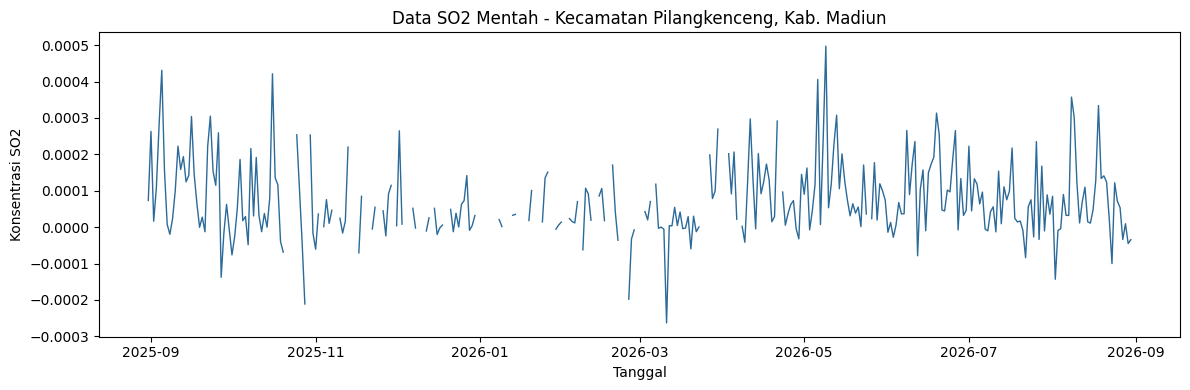

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["SO2"], color="#2b6a99", linewidth=1)
ax.set_title("Data SO2 Mentah - Kecamatan Pilangkenceng, Kab. Madiun")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi SO2")
plt.tight_layout()
plt.show()


### Deteksi Outlier (Metode IQR)

Metode yang digunakan sama seperti pada NO2. Data dianggap outlier jika berada di luar rentang $[\,Q_1 - 1.5 \times IQR,\ \ Q_3 + 1.5 \times IQR\,]$ dengan $IQR = Q_3 - Q_1$. Nilai outlier diubah menjadi kosong (NaN) terlebih dahulu, untuk kemudian diisi ulang pada tahap imputasi.

In [17]:
Q1 = df["SO2"].quantile(0.25)
Q3 = df["SO2"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df["SO2"] < lower_bound) | (df["SO2"] > upper_bound)
n_outliers = outlier_mask.sum()

print(f"Q1  = {Q1:.6e}")
print(f"Q3  = {Q3:.6e}")
print(f"IQR = {IQR:.6e}")
print(f"Batas bawah = {lower_bound:.6e}")
print(f"Batas atas  = {upper_bound:.6e}")
print(f"Jumlah outlier terdeteksi: {n_outliers}")

df_clean = df.copy()
df_clean.loc[outlier_mask, "SO2"] = np.nan

print("Total missing setelah outlier dikosongkan:", df_clean["SO2"].isna().sum())


Q1  = 4.088093e-06
Q3  = 1.242217e-04
IQR = 1.201336e-04
Batas bawah = -1.761123e-04
Batas atas  = 3.044221e-04
Jumlah outlier terdeteksi: 12
Total missing setelah outlier dikosongkan: 71


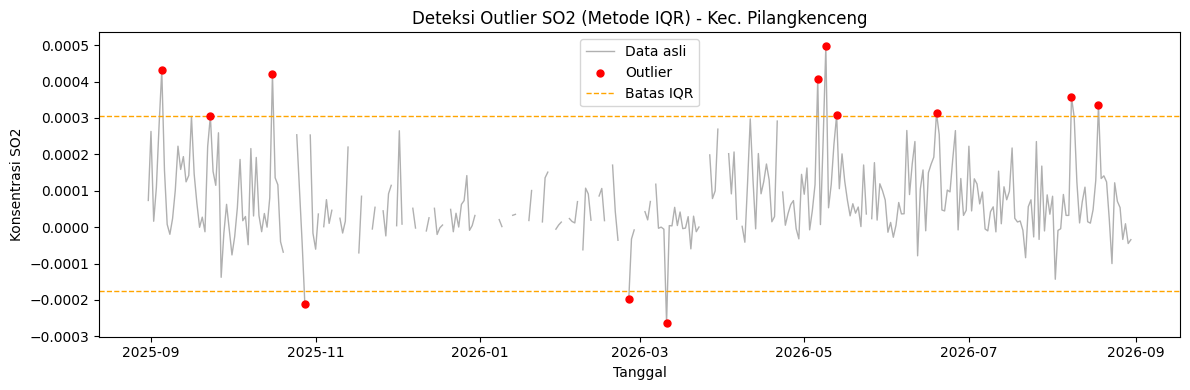

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["SO2"], color="#b0b0b0", linewidth=1, label="Data asli")
ax.scatter(df.index[outlier_mask], df["SO2"][outlier_mask], color="red", s=25, zorder=5, label="Outlier")
ax.axhline(upper_bound, color="orange", linestyle="--", linewidth=1, label="Batas IQR")
ax.axhline(lower_bound, color="orange", linestyle="--", linewidth=1)
ax.set_title("Deteksi Outlier SO2 (Metode IQR) - Kec. Pilangkenceng")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi SO2")
ax.legend()
plt.tight_layout()
plt.show()


**Catatan:** Pada SO2, batas bawah IQR bernilai negatif (sekitar −1.76×10⁻⁴). Kolom SO2 di wilayah tanpa sumber emisi besar berada sangat dekat dengan nol, sehingga hasil retrieval TROPOMI dapat bernilai negatif akibat noise pengukuran (pada data mentah terdapat 67 hari bernilai negatif). Nilai negatif yang masih berada di dalam batas IQR tidak dianggap outlier dan tetap dipertahankan. Hanya nilai di luar batas (12 hari, 3 di antaranya di sisi bawah) yang dikosongkan lalu diimputasi.

### Imputasi Missing Value

Sama seperti NO2: nilai kosong (dari data asli yang tidak memiliki citra valid pada hari tersebut, maupun dari hasil deteksi outlier) diisi dengan interpolasi berbasis waktu (`interpolate(method='time')`), kemudian forward-fill dan backward-fill untuk sisa nilai kosong di ujung awal/akhir data.

Pada SO2, 59 hari kosong dari data asli ditambah 12 outlier menghasilkan 71 nilai (19.5% dari 365 hari) yang diimputasi. Hasil akhirnya adalah dataset SO2 tanpa nilai kosong dan tanpa outlier, siap diekstraksi fiturnya.

In [19]:
df_clean["SO2"] = df_clean["SO2"].interpolate(method="time")
df_clean["SO2"] = df_clean["SO2"].ffill().bfill()

print("Jumlah missing value setelah imputasi:", df_clean["SO2"].isna().sum())
df_clean.head()


Jumlah missing value setelah imputasi: 0


,SO2
date,
2025-08-31,0.000073
2025-09-01,0.000263
2025-09-02,0.000016
2025-09-03,0.000109
2025-09-04,0.000280


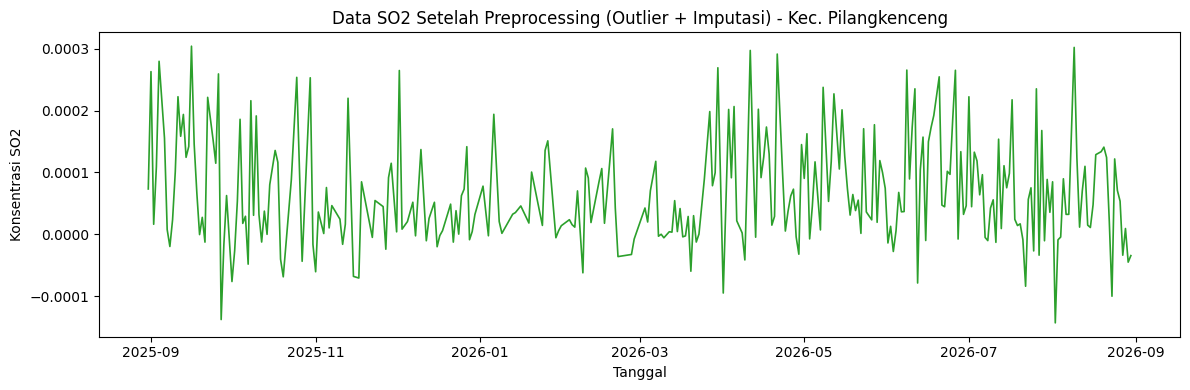

Tersimpan: SO2-Pilangkenceng-Clean.csv


In [20]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_clean.index, df_clean["SO2"], color="#2ca02c", linewidth=1.2)
ax.set_title("Data SO2 Setelah Preprocessing (Outlier + Imputasi) - Kec. Pilangkenceng")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi SO2")
plt.tight_layout()
plt.show()

df_clean.to_csv("SO2-Pilangkenceng-Clean.csv")
print("Tersimpan: SO2-Pilangkenceng-Clean.csv")


## 3. Ekstraksi 68 Fitur dengan TSFEL

Tahap ini identik dengan NO2. Data SO2 yang sudah bersih (1 tahun, harian) diekstraksi menggunakan konfigurasi domain bawaan TSFEL, menghasilkan **68 fitur** yang masing-masing meringkas satu karakteristik dari keseluruhan data setahun menjadi 1 angka. Fitur yang menghasilkan banyak nilai (MFCC, LPCC, wavelet per skala) diringkas menjadi 1 nilai dengan rata-rata.

In [21]:
import inspect
import tsfel
import tsfel.feature_extraction.features as tsfel_features

signal_1d = df_clean["SO2"].astype(float).values
fs = 1  

FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    """Fitur TSFEL yang menghasilkan banyak nilai (mis. MFCC, LPCC, wavelet per skala)
    diringkas menjadi 1 nilai representatif lewat rata-rata."""
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

features_df = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk SO2: {features_df.shape[1]}")
features_df


Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk SO2: 68


,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,0.000004,0.025926,1.0,1.095178e-08,183.041373,0.000304,0.000065,0.000045,-0.000143,0.000082,...,0.15166,0.318823,1.162739e-08,0.026299,0.000005,0.000093,2.188757,0.000093,8.791744e-09,95.0


In [22]:
features_df.to_csv("SO2_Pilangkenceng_TSFEL.csv", index=False)
print("Tersimpan: SO2_Pilangkenceng_TSFEL.csv")


Tersimpan: SO2_Pilangkenceng_TSFEL.csv


## 4. Pengelompokan Fitur Berdasarkan Domain

Pengelompokan domain memakai cara yang sama dengan NO2, yaitu dari konfigurasi resmi TSFEL (`tsfel.get_features_by_domain()`), dengan kelompok `fractal` digabungkan ke domain **Temporal**.

In [23]:
cfg_all_domains = tsfel.get_features_by_domain()  

function_to_domain = {}
for domain_name, feats in cfg_all_domains.items():
    for feat_display_name, feat_info in feats.items():
        fn_full_name = feat_info.get("function", "")
        fn_short_name = fn_full_name.split(".")[-1]
        normalized_domain = "temporal" if domain_name == "fractal" else domain_name
        function_to_domain[fn_short_name] = normalized_domain

domain_rows = []
for fn_name in FEATURE_LIST:
    domain = function_to_domain.get(fn_name, "unknown")
    domain_rows.append({"feature": fn_name, "domain": domain})

mapping_df = pd.DataFrame(domain_rows)

print("Ringkasan jumlah fitur per domain:")
domain_counts = mapping_df["domain"].value_counts()
print(domain_counts)

unknown_feats = mapping_df[mapping_df["domain"] == "unknown"]
if len(unknown_feats) > 0:
    print("\nPERHATIAN, fitur berikut tidak ketemu mapping domain-nya otomatis, "
          "cek manual ke dokumentasi TSFEL:")
    print(unknown_feats["feature"].tolist())

mapping_df = mapping_df.sort_values(["domain", "feature"]).reset_index(drop=True)
mapping_df.to_csv("SO2_Pilangkenceng_TSFEL_domain_mapping.csv", index=False)
print("\nTotal fitur:", domain_counts.sum())


Ringkasan jumlah fitur per domain:
domain
spectral       26
temporal       21
statistical    20
unknown         1
Name: count, dtype: int64

PERHATIAN, fitur berikut tidak ketemu mapping domain-nya otomatis, cek manual ke dokumentasi TSFEL:
['ecdf_slope']

Total fitur: 68


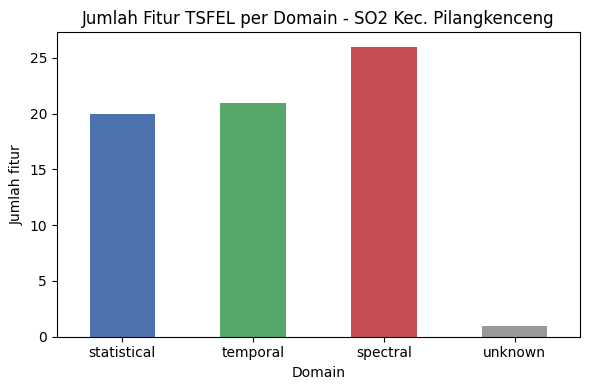

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
domain_counts.reindex(["statistical", "temporal", "spectral", "unknown"]).fillna(0).plot(
    kind="bar", color=["#4c72b0", "#55a868", "#c44e52", "#999999"], ax=ax
)
ax.set_title("Jumlah Fitur TSFEL per Domain - SO2 Kec. Pilangkenceng")
ax.set_ylabel("Jumlah fitur")
ax.set_xlabel("Domain")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Ringkasan:** Statistical (20) + Temporal (21) + Spectral (26) + Unknown (1) = **68 fitur**. Hasilnya identik dengan NO2, termasuk `ecdf_slope` sebagai satu-satunya fitur yang tidak terpetakan otomatis. Daftar fitur pada tiap domain sama dengan yang tercantum pada Bagian 1 (NO2).

## 5. Hasil & Interpretasi

In [25]:
def show(col):
    val = features_df[col].iloc[0]
    print(f"{col:>20s} : {val:.6e}")

for col in ["calc_mean", "calc_std", "skewness", "kurtosis", "spectral_entropy", "autocorr", "hurst_exponent", "zero_cross"]:
    if col in features_df.columns:
        show(col)


           calc_mean : 6.493568e-05
            calc_std : 8.188490e-05
            skewness : 7.012677e-01
            kurtosis : 2.758054e-01
    spectral_entropy : 9.022568e-01
            autocorr : 1.000000e+00
      hurst_exponent : 6.752525e-01
          zero_cross : 9.500000e+01


In [26]:
# Pelengkap interpretasi: autokorelasi harian dan rata-rata per bulan
s = df_clean["SO2"]
print("ACF lag-1 :", round(s.autocorr(1), 3))
print("Jumlah nilai negatif pada data bersih:", int((s < 0).sum()), f"({(s < 0).mean()*100:.1f}%)")
print("Jumlah nilai hasil imputasi          :", int(df["SO2"].isna().sum() + outlier_mask.sum()), "dari", len(s))
print()
monthly = s.groupby(s.index.to_period("M")).agg(["mean", "count"])
monthly.columns = ["rata-rata", "jumlah_hari"]
monthly

ACF lag-1 : 0.272
Jumlah nilai negatif pada data bersih: 71 (19.5%)
Jumlah nilai hasil imputasi          : 71 dari 365



,rata-rata,jumlah_hari
date,,
2025-08,0.000073,1
2025-09,0.000112,30
2025-10,0.000065,31
2025-11,0.000032,30
2025-12,0.000040,31
2026-01,0.000052,31
2026-02,0.000030,28
2026-03,0.000048,31
2026-04,0.000088,30


**Interpretasi nilai kunci** (angka mengikuti hasil eksekusi sel di atas):

- **`calc_mean`** (rata-rata SO2 setahun) sekitar **6.49×10⁻⁵ mol/m²** dengan `calc_median` ≈ 4.55×10⁻⁵, sedangkan **`calc_std`** ≈ 8.19×10⁻⁵ justru lebih besar daripada rata-ratanya (koefisien variasi ≈ 126%). Artinya fluktuasi harian lebih besar daripada level rata-rata SO2 itu sendiri, dengan rentang nilai −1.43×10⁻⁴ sampai 3.04×10⁻⁴.
- Sebanyak **71 dari 365 nilai (19.5%)** pada data bersih bernilai negatif (`calc_min` juga negatif). Kolom SO2 tidak mungkin negatif secara fisik, sehingga ini adalah noise pengukuran dan menjadi tanda bahwa kadar SO2 di wilayah ini sangat rendah, mendekati batas kemampuan deteksi sensor.
- **`skewness`** ≈ 0.70 (miring ke kanan, lebih kuat daripada NO2 ≈ 0.33 dan CO ≈ 0.29) dan **`kurtosis`** ≈ 0.28 (mendekati sebaran normal). Median yang lebih kecil daripada mean menunjukkan adanya sejumlah hari dengan nilai tinggi yang menarik rata-rata ke atas.
- **`spectral_entropy`** ≈ 0.90, mendekati 1 dan tertinggi di antara tiga polutan (NO2 ≈ 0.84, CO ≈ 0.67). Deret SO2 menyerupai noise acak tanpa periodisitas yang dominan.
- **`autocorr`** = 1, artinya autokorelasi sudah turun di bawah 1/e pada lag 1 hari (ACF lag-1 ≈ 0.27). Nilai SO2 hampir tidak berhubungan dengan hari sebelumnya, berbeda jauh dengan CO (17 hari).
- **`hurst_exponent`** ≈ 0.68 memang di atas 0.5, tetapi autokorelasi yang sangat lemah menunjukkan sifat *persistent*-nya lemah, sehingga nilai ini sebaiknya ditafsirkan dengan hati-hati.
- **`zero_cross`** = 95, yaitu sinyal berpindah tanda sebanyak 95 kali karena nilainya berayun di sekitar nol. Pada NO2 dan CO nilainya 0 karena seluruh nilai positif.

## Interpretasi Umum

- **Sumber emisi**: kadar SO2 yang rendah sesuai dengan karakter wilayah pertanian dan permukiman tanpa industri berat. Sumber SO2 utama (pembakaran batu bara dan proses industri) tidak dominan di sini.
- **Sifat data**: sebagian besar variasi harian SO2 kemungkinan mencerminkan noise pengukuran, bukan perubahan emisi yang nyata. Fitur temporal dan spektral SO2 lebih tepat dibaca sebagai karakteristik noise daripada pola aktivitas penduduk.
- **Pola bulanan**: rata-rata bulanan bervariasi antara ≈ 3×10⁻⁵ (Februari 2026) dan ≈ 1.1×10⁻⁴ (September 2025). Nilainya cenderung lebih rendah pada November 2025–Maret 2026 dan lebih tinggi pada April–Juni 2026, tetapi karena data harian sangat berisik, pola ini perlu dikonfirmasi dengan data yang lebih panjang sebelum dijadikan kesimpulan.
- **Catatan keterbatasan**: 71 dari 365 nilai (19.5%) berasal dari imputasi, sehingga sekitar satu dari lima titik pada deret bersih adalah hasil interpolasi, bukan pengukuran langsung.
